In [69]:
import kagglehub
import pandas as pd
import os
#import ast
import matplotlib.pyplot as plt
from jinja2 import Template
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, recall_score, precision_score, f1_score,roc_curve, silhouette_score, precision_recall_curve, average_precision_score
from xgboost import XGBClassifier
from sklearn.inspection import permutation_importance
import plotly.graph_objects as go
import plotly.express as px

In [70]:
# =========================
# DATA LOADING
# =========================
path = kagglehub.dataset_download(
    "blastchar/telco-customer-churn"
)

csv_path = os.path.join(
    path,
    "WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

df = pd.read_csv(csv_path)

Data Cleaning
Coverting TotalCharges to numeric and removing NaN values (only 4 present in set.)
Establish dummy variables for categorical columns and prepare x_raw by removing target variable and ID.

In [71]:
# =========================
# DATA CLEANING
# =========================
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

categorical_cols = df.select_dtypes(include=['object','str']).columns
categorical_cols = categorical_cols.drop('customerID')
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

x_raw = df_encoded.drop('Churn', axis=1)
x_raw = x_raw.drop('customerID', axis=1)


Clustering
Data is scaled and PCA to allow for simple clustering visualization. PCA is NOT currently used in modeling to preserve model explainability to business stakeholders.

Uses kmeans cluster for determining cluster size, normalized churn rates, total revenue by cluster, and average tenure by cluster.

Currently, clustering group size was chosen visually. Future iterations will use elbow or silhouette to validate.



Text(0, 0.5, 'Average Silhouette Score')

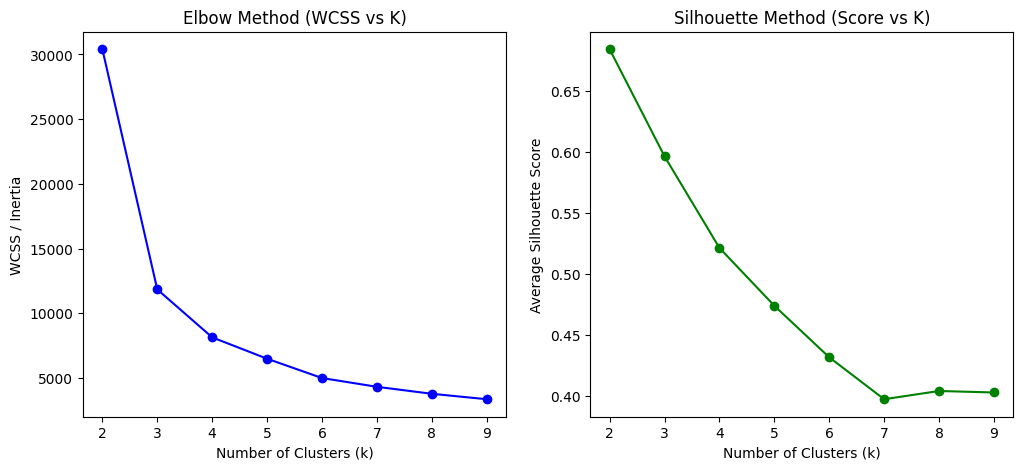

In [72]:
# =========================
# FEATURE ENGINEERING
# =========================
cluster_features = StandardScaler().fit_transform(x_raw)
pca = PCA(n_components = 2)
x_pca = pca.fit_transform(cluster_features)
y = df['Churn']
x_cluster = x_pca

wcss = []
silhouette_scores = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=123)
    kmeans.fit(x_cluster)
    labels = kmeans.labels_
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(x_cluster, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Elbow Method Plot
ax1.plot(k_range, wcss, marker='o', color='blue')
ax1.set_title('Elbow Method (WCSS vs K)')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('WCSS / Inertia')

# Silhouette Method Plot
ax2.plot(k_range, silhouette_scores, marker='o', color='green')
ax2.set_title('Silhouette Method (Score vs K)')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Average Silhouette Score')


Based on the Elbow and Silhouette methods above, 3 clusters is clearly the highest value inflection point.

Cluster profiles were derived using unsupervised PCA space. Churn rattes are discussed post-hoc for interpretation, not for model training.

Analysis:
Cluster 0 - Has the highest number of customers, has a 44% churn rate, represents about 22% of overall revenue at $3.55M with lowest average tenure at 16 months.
Cluster 1 - Smallest group, only 7% churn, 6.2% revenue at 1.01M, and second highest tenure at 31 months.
Cluster 2 - Middle group numbers-wise, relatively low churn at 15%, accounts for 72% off all revenue at 11.50M, with average tenure at 56 months.

,Number_of_Customers
Cluster,
2,3200
1,2312
0,1520


Churn,0,1
Cluster,,
2,56.0,44.0
1,85.0,15.0
0,93.0,7.0


,Total_Revenue
Cluster,
1,"$11,510,955.60"
2,"$3,534,078.20"
0,"$1,011,134.90"


,Avg_Tenure
Cluster,
1,55.5 months
0,30.7 months
2,16.6 months


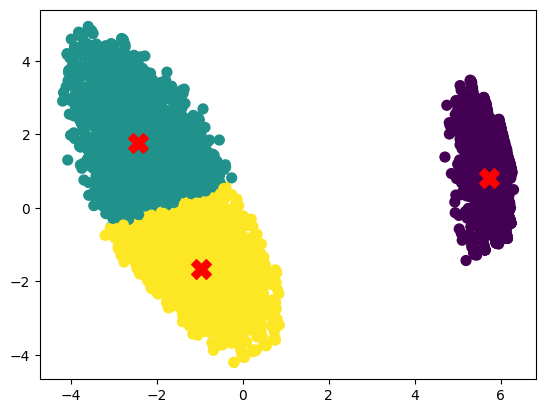

In [73]:
# =========================
# CLUSTERING ANALYSIS
# =========================
kmeans = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=123)
y_kmeans = kmeans.fit_predict(x_cluster)

cluster_df = df.copy()
cluster_df['Cluster'] = y_kmeans

display(
        cluster_df.groupby('Cluster')
        .agg(Number_of_Customers=('Cluster','count'))
        .sort_values(['Number_of_Customers'], ascending=False)
        )

display(cluster_df.groupby('Cluster')['Churn']
        .value_counts(normalize=True).round(2).mul(100)
        .unstack()
        .sort_values(by= 1, ascending=False)        
)

display(
    cluster_df.groupby('Cluster')
    .agg(Total_Revenue=('TotalCharges','sum'))
    .sort_values(['Total_Revenue'], ascending=False) 
    .style.format({'Total_Revenue': '${:,.2f}'})
        
        
    )

display(
    cluster_df.groupby('Cluster')
    .agg(Avg_Tenure=('tenure','mean'))
    .sort_values(['Avg_Tenure'], ascending=False)
         .style.format({'Avg_Tenure': '{:.1f} months'})
)

plt.scatter(x_cluster[:, 0], x_cluster[:, 1], c=y_kmeans, s=50, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='red', marker='X')
plt.show()

cluster_summary = (
    cluster_df
    .groupby('Cluster')
    .agg(
        Customers=('Churn', 'count'),
        ChurnRate=('Churn', 'mean')
    )
    .reset_index()
)

cluster_summary['ChurnRate'] *= 100

rev_summary = (
    cluster_df
    .groupby('Cluster')
    .agg(Total_Revenue=('TotalCharges', 'sum'))
    .reset_index()
)

rev_summary['Revenue_Label'] = (
    rev_summary['Total_Revenue'] / 1000
).round(1).astype(str) + 'K'

avg_charges_summary = (
    cluster_df
    .groupby('Cluster')
    .agg(Avg_Charges=('MonthlyCharges', 'mean'))
    .reset_index()
)

avg_tenure_summary = (
    cluster_df
    .groupby('Cluster')
    .agg(Avg_Tenure=('tenure', 'mean'))
    .reset_index()
)

fig = px.bar(
    cluster_summary,
    x='Cluster',
    y='ChurnRate',
    text='ChurnRate',
    title='Customer Churn Rate by Cluster'
)

fig.update_traces(
    texttemplate='%{text:.1f}%',
    textposition='auto'
)

fig.update_layout(
        yaxis_range=[
        0,
        cluster_summary['ChurnRate'].max() * 1.15
    ],
    yaxis_title='Churn Rate (%)',
    xaxis_title='Cluster'
)

fig.show()

fig2 = px.bar(
    rev_summary,
    x='Cluster',
    y='Total_Revenue',
    text='Revenue_Label',
    title='Total Revenue by Cluster'
)

fig2.update_traces(
   ## texttemplate='$%{text:,.0f}',
    textposition='auto'
)

fig2.update_layout(
    yaxis_range=[
        0,
        rev_summary['Total_Revenue'].max() * 1.15
    ],
    yaxis_title='Total Revenue ($)',
    xaxis_title='Cluster'
)
fig2.show()

fig3 = px.bar(
    avg_charges_summary,
    x='Cluster',
    y='Avg_Charges',
    text='Avg_Charges',
    title='Average MonthlyCharges by Cluster'
)

fig3.update_traces(
    texttemplate='$%{text:,.2f}',
    textposition='auto'
)

fig3.update_layout(
    yaxis_range=[
        0,
        avg_charges_summary['Avg_Charges'].max() * 1.15
    ],
    yaxis_title='Average Charges ($)',
    xaxis_title='Cluster'
)

fig3.show()

fig4 = px.bar(
    avg_tenure_summary,
    x='Cluster',
    y='Avg_Tenure',
    text='Avg_Tenure',
    title='Average Tenure by Cluster'
)

fig4.update_traces(
    texttemplate='%{text:.1f} months',
    textposition='auto'
)

fig4.update_layout(
    yaxis_range=[
        0,
        avg_tenure_summary['Avg_Tenure'].max() * 1.15
    ],
    yaxis_title='Average Tenure (months)',
    xaxis_title='Cluster'
)
fig4.show()

Model Building Function

Accepts raw data (x_raw), target variable (y), a list of modeling methodologies (methods), and a simple boolean that determines whether or not to draw the ROC Curve (GenPlot).

Function returns a dictionary that includes model name, accuracy score, precision, recall, F1, and AUC.

In [74]:
# =========================
# MODELING Function
# =========================
def build_models(X, y, models, gen_plot=False):
    """
    Train and evaluate multiple models using stratified CV.
    
    Parameters:
    -----------
    X : pd.DataFrame
        Feature matrix (raw, unscaled)
    y : pd.Series or np.array
        Target variable
    models : list
        List of sklearn-compatible estimators (or pipelines)
    gen_plot : bool
        Whether to generate ROC and PR curves
    
    Returns:
    --------
    pd.DataFrame
        Model comparison table
    dict
        Feature importance (if applicable)
    """

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

    results = []
    feature_importances = {}

    roc_fig = go.Figure()
    pr_fig = go.Figure()

    baseline = y.mean()

    for model_name, model in models:


        # ---------------------------------------------------------
        # Build pipeline if model is NOT already a pipeline
        # ---------------------------------------------------------
        if not hasattr(model, "steps"):
            model = Pipeline([
                ("scaler", StandardScaler()),
                ("model", model)
            ])

        # ---------------------------------------------------------
        # Cross-validated metrics
        # ---------------------------------------------------------
        scores = cross_validate(
            model,
            X,
            y,
            cv=skf,
            scoring=["accuracy", "precision", "recall", "f1", "roc_auc"]
        )

        # ---------------------------------------------------------
        # Cross-validated probabilities (for ROC / PR)
        # ---------------------------------------------------------
        y_proba = cross_val_predict(
            model,
            X,
            y,
            cv=skf,
            method="predict_proba"
        )[:, 1]

        auc = roc_auc_score(y, y_proba)

        # ---------------------------------------------------------
        # ROC + PR data
        # ---------------------------------------------------------
        fpr, tpr, _ = roc_curve(y, y_proba)
        precision, recall, _ = precision_recall_curve(y, y_proba)
        ap_score = average_precision_score(y, y_proba)

        # ---------------------------------------------------------
        # Feature importance (best-effort, model-dependent)
        # ---------------------------------------------------------
        fitted_model = model.fit(X, y)

        estimator = (
            fitted_model.named_steps["model"]
            if hasattr(fitted_model, "named_steps")
            else fitted_model
        )

        #Note: permutation importance computerd on full dataset for interpretability, not CV folds
        pi = permutation_importance(
            model,
            X,
            y,
            n_repeats=10,
            random_state=123,
            scoring="roc_auc"
        )

        perm_importance = pd.Series(
            pi.importances_mean,
            index=X.columns
        ).sort_values(ascending=False)

        feature_importances[model_name] = perm_importance

        # ---------------------------------------------------------
        # Store results
        # ---------------------------------------------------------
        results.append({
            "model": model_name,
            "accuracy": scores["test_accuracy"].mean(),
            "precision": scores["test_precision"].mean(),
            "recall": scores["test_recall"].mean(),
            "f1": scores["test_f1"].mean(),
            "auc": scores["test_roc_auc"].mean(),
            "auc_std": scores["test_roc_auc"].std(),
            "ap_score": ap_score
        })

        # ---------------------------------------------------------
        # Plots
        # ---------------------------------------------------------
        if gen_plot:
            roc_fig.add_trace(
                go.Scatter(
                    x=fpr,
                    y=tpr,
                    mode="lines",
                    name=f"{model_name} (AUC={auc:.3f})"
                )
            )

            pr_fig.add_trace(
                go.Scatter(
                    x=recall,
                    y=precision,
                    mode="lines",
                    name=f"{model_name} (AP={ap_score:.3f})"
                )
            )

    # -------------------------------------------------------------
    # Plot final layout
    # -------------------------------------------------------------
    if gen_plot:

        roc_fig.add_trace(
            go.Scatter(
                x=[0, 1],
                y=[0, 1],
                mode="lines",
                name="Random Baseline",
                line=dict(dash="dash")
            )
        )

        roc_fig.update_layout(
            title="ROC Curve Comparison (Cross-Validated)",
            xaxis_title="False Positive Rate",
            yaxis_title="True Positive Rate"
        )

        pr_fig.add_trace(
            go.Scatter(
                x=[0, 1],
                y=[baseline, baseline],
                mode="lines",
                name=f"Baseline ({baseline:.2f})",
                line=dict(dash="dash")
            )
        )

        pr_fig.update_layout(
            title="Precision-Recall Curve Comparison (Cross-Validated)",
            xaxis_title="Recall",
            yaxis_title="Precision"
        )

        roc_fig.show()
        pr_fig.show()

    return pd.DataFrame(results).sort_values("auc", ascending=False), feature_importances

Model Building and Results

Defines the list of modeling methodologies to try, passes to the build_models function, stores the result in a dataframe that is then formatted for output to be sorted by AUC score, highlighting the maximum value of each scoring metric to compare model types.

Currently, the winning model is logistic regression for both its high scoring on all metrics except recall (losing slightly to random forest) and because it is also the simplist model. 

In future iterations stability will be checked for models, evaluate if clustering adds value to the model, perform cross-validation.
May further explore hyperparameter tuning though dataset is small enough that there is likely not much to be gained and may be subject to overfitting.

In [75]:
# =========================
# 5. MODELING
# =========================

models = [
    ("Logistic Regression", Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000))
    ])),
    ("Random Forest", Pipeline([
        ("model", RandomForestClassifier(
            n_estimators=50,
            max_depth=10,
            min_samples_leaf=50,
            random_state=123
        ))
    ])),
    ("XGBoost", Pipeline([
        ("model", XGBClassifier(
            max_depth=6,
            learning_rate=0.05,
            n_estimators=300,
            scale_pos_weight=0.74
        ))
    ]))
]

model_results, feature_importances = (
        build_models(x_raw,y,models,True)
        )
           
model_results.index += 1
model_results.index.name = "Rank"

fi_df = pd.DataFrame(feature_importances)

display_results = (model_results
    .sort_values("auc", ascending=False)
    .style
    .format("{:.3f}", subset=["accuracy","precision","recall","f1","auc","auc_std","ap_score"])
    .highlight_max(
        subset=["accuracy","precision","recall","f1","auc","auc_std","ap_score"],
        axis=0,
        color='blue'
        )
)

display(display_results)

# for model in fi_df.columns:
#     display(
#         fi_df[model]
#         .sort_values(ascending=False)
#         .head(15)
#         .to_frame(name="importance")
#     )


top_n = 20

top_features = (
    fi_df.mean(axis=1)
    .sort_values(ascending=False)
    .head(top_n)
    .index
)

fi_top = fi_df.loc[top_features]

fi_norm = fi_top.apply(lambda x: x / x.sum(), axis=0)

fig = px.imshow(
    fi_norm,
    color_continuous_scale="Viridis",
    aspect="auto",
    title="Permutation Feature Importance (Normalized)"
)

fig.update_layout(height=700)
fig.show()

driver_strength = fi_norm.mean(axis=1).sort_values(ascending=False)
top_drivers = driver_strength.head(10)

driver_table = top_drivers.reset_index()
driver_table.columns = ["Feature", "Importance"]

def map_driver(feature):
    if "InternetService" in feature:
        return "Service Type Risk"
    if "Contract" in feature:
        return "Contract Stickiness"
    if "PaymentMethod" in feature or "MonthlyCharges" in feature:
        return "Pricing Sensitivity"
    if "tenure" in feature or "TotalCharges" in feature:
        return "Customer Lifecycle"
    if "TechSupport" in feature or "OnlineSecurity" in feature:
        return "Support Engagement"
    return "Other"

driver_table["Category"] = driver_table["Feature"].apply(map_driver)

summary = (
    driver_table
    .groupby("Category")
    .agg(
        Total_Importance=("Importance", "sum"),
        Feature_Count=("Feature", "count")
    )
    .sort_values("Total_Importance", ascending=False)
)
display(driver_table)
display(summary)

,model,accuracy,precision,recall,f1,auc,auc_std,ap_score
Rank,,,,,,,,
1,Logistic Regression,0.805,0.662,0.551,0.601,0.845,0.009,0.655
2,Random Forest,0.800,0.682,0.469,0.555,0.845,0.009,0.658
3,XGBoost,0.794,0.673,0.440,0.531,0.837,0.007,0.650


,Feature,Importance,Category
0,tenure,0.394410,Customer Lifecycle
1,Contract_Two year,0.122353,Contract Stickiness
2,TotalCharges,0.107941,Customer Lifecycle
3,InternetService_Fiber optic,0.103370,Service Type Risk
4,MonthlyCharges,0.083235,Pricing Sensitivity
5,Contract_One year,0.033274,Contract Stickiness
6,PaymentMethod_Electronic check,0.027957,Pricing Sensitivity
7,OnlineSecurity_Yes,0.019375,Support Engagement
8,TechSupport_Yes,0.015011,Support Engagement
9,PaperlessBilling_Yes,0.014463,Other


,Total_Importance,Feature_Count
Category,,
Customer Lifecycle,0.502351,2
Contract Stickiness,0.155627,2
Pricing Sensitivity,0.111191,2
Service Type Risk,0.103370,1
Support Engagement,0.034386,2
Other,0.014463,1
